In [1]:
import numpy as np
import pandas as pd

import scarf

scarf.configure_output(level="WARNING", progress=False)

dataset = scarf.cytebase.connect("scarf_docs").download_dataset(
    "tenx_5K_pbmc_rnaseq",
    destination="scarf_datasets",
    zarr=True,
)
ds = scarf.DataStore(f"{dataset}/data.zarr", nthreads=4)
run = ds.pipeline.open(label="docs_default")
clusters = run["clusters"]
markers = run["markers"]
cluster_values = np.asarray(run.cells.fetch("clusters"))

In [2]:
group_id = pd.Series(cluster_values).value_counts().index[0]
group_markers = ds.get_markers(
    marker=markers,
    group_id=group_id,
    min_score=-1,
    min_frac_exp=-1,
)
group_markers[
    [
        "feature_name",
        "score",
        "frac_exp",
        "fold_change",
        "auc",
        "p_value",
        "p_value_adjusted",
    ]
].head(12)

,feature_name,score,frac_exp,fold_change,auc,p_value,p_value_adjusted
0,ADTRP,0.41057,0.24203,7.01255,0.60208,2.122675e-83,3.727239e-81
1,FHIT,0.34388,0.62251,6.12971,0.75649,1.297768e-216,1.554448e-213
2,ANKRD55,0.33443,0.14044,6.21225,0.55836,2.183907e-45,1.441808e-43
3,TSHZ2,0.31510,0.32072,3.96487,0.62291,4.188060e-84,7.471232e-82
4,AL031280.1,0.31406,0.16335,4.60520,0.56289,8.361570e-41,4.604767e-39
5,CMTM8,0.31237,0.30578,3.71605,0.61065,2.354141e-65,2.892058e-63
6,EPHX2,0.31103,0.38745,4.61110,0.64836,3.218353e-101,7.709795e-99
7,AC009041.2,0.31035,0.14741,5.86866,0.56065,6.169623e-46,4.154956e-44
8,LRRN3,0.30605,0.53785,5.81899,0.72201,1.099399e-191,9.703067e-189
9,CHRM3-AS2,0.30605,0.36952,4.24173,0.64164,3.369847e-97,7.435389e-95


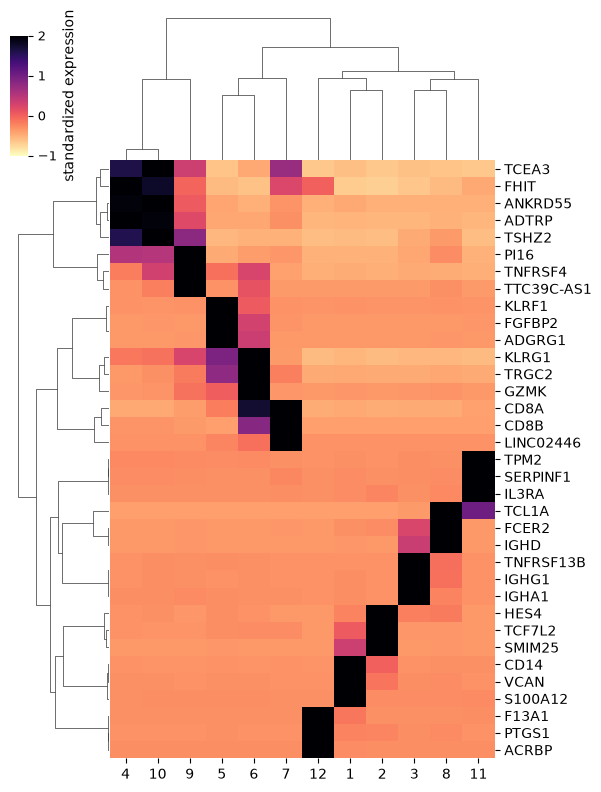

In [3]:
ds.plots.marker_heatmap(
    marker=markers,
    topn=3,
    figsize=(6, 8),
)

In [4]:
label_map = {
    "1": "CD14 monocytes",
    "2": "FCGR3A monocytes",
    "3": "B cells",
    "4": "T cells",
    "5": "NK cells",
    "6": "T cells",
    "7": "T cells",
    "8": "B cells",
    "9": "T cells",
    "10": "T cells",
    "11": "pDC-like cells",
    "12": "Platelets",
}
observed = {str(value) for value in np.unique(cluster_values)}
assert observed == set(label_map)

analysis_cells = np.asarray(run.cells.fetch_all("I"), dtype=bool)
cell_type = np.full(len(analysis_cells), "Not analyzed", dtype=object)
cell_type[analysis_cells] = [label_map[str(value)] for value in cluster_values]
ds.cells.insert("reviewed_cell_type", cell_type, overwrite=True)
pd.Series(cell_type[analysis_cells]).value_counts()

T cells             2374
CD14 monocytes       694
B cells              500
NK cells             317
FCGR3A monocytes      28
pDC-like cells        15
Platelets             12
Name: count, dtype: int64

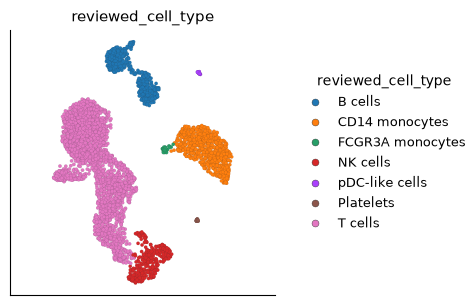

In [5]:
ds.plots.embedding(
    layout=run["umap"],
    color_by="reviewed_cell_type",
    legend_loc="right",
)